### 1. IMPORTAR LIBRERÍAS

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import tensorflow.keras.backend as K

from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.10.0


### 2. PARÁMETROS

In [2]:
IMG_SIZE      = 224
BATCH_SIZE    = 32
EPOCHS        = 75
NUM_CLASSES   = 10
NOMBRE_MODELO = 'resnet50_desde_plantvillage'

PATIENCE_ES_F1 = 10
PATIENCE_LR_F1 = 5

# Ruta de los pesos entrenados en PlantVillage
PESOS_PLANTVILLAGE = '../../PlantVillage_Preentrenamiento/pesos_resnet50/resnet50_backbone_plantvillage.h5'

In [3]:
# Confirmar que el archivo de pesos existe

if os.path.exists(PESOS_PLANTVILLAGE):
    print(f"Archivo de pesos encontrado: {PESOS_PLANTVILLAGE}")
    tamano_mb = os.path.getsize(PESOS_PLANTVILLAGE) / (1024 * 1024)
    print(f"   Tamaño: {tamano_mb:.2f} MB")
else:
    print(f"ERROR: No se encontró el archivo: {PESOS_PLANTVILLAGE}")
    print("Revisa la ruta antes de continuar.")

Archivo de pesos encontrado: ../../PlantVillage_Preentrenamiento/pesos_resnet50/resnet50_backbone_plantvillage.h5
   Tamaño: 90.39 MB


### 3. PREPROCESAMIENTO

In [4]:
base_dir  = '../../../Data/Cana_de_azucar'
train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'val')
test_dir  = os.path.join(base_dir, 'test')

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2]
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f'Imágenes de entrenamiento : {train_generator.samples}')
print(f'Imágenes de validación    : {val_generator.samples}')
print(f'Imágenes de test          : {test_generator.samples}')

Found 6112 images belonging to 10 classes.
Found 1309 images belonging to 10 classes.
Found 1309 images belonging to 10 classes.
Imágenes de entrenamiento : 6112
Imágenes de validación    : 1309
Imágenes de test          : 1309


### 4. CONSTRUCCIÓN DEL MODELO

In [5]:
# Crear el backbone vacío (sin pesos), se cargaran manualmente
base_model = ResNet50(
    weights=None,
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.load_weights(PESOS_PLANTVILLAGE)
print("Pesos de PlantVillage cargados correctamente en el backbone")

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    ),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name=NOMBRE_MODELO)

model.summary()

Pesos de PlantVillage cargados correctamente en el backbone
Model: "resnet50_desde_plantvillage"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               262272    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 23,851,274
Trainable params: 26

### 5. COMPILAR EL MODELO

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### 6. ENTRENAMIENTO

In [7]:
print('Entrenando cabeza clasificadora (backbone congelado)')

early_stopping_fase1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE_ES_F1,
    restore_best_weights=True,
    verbose=1
)

checkpoint_fase1 = tf.keras.callbacks.ModelCheckpoint(
    filepath=f'{NOMBRE_MODELO}_fase1_weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

reduce_lr_fase1 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=PATIENCE_LR_F1,
    min_lr=1e-6,
    verbose=1
)

history_fase1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping_fase1, checkpoint_fase1, reduce_lr_fase1]
)

print(f'Mejor val_accuracy {max(history_fase1.history["val_accuracy"]):.4f}')

Entrenando cabeza clasificadora (backbone congelado)
Epoch 1/75
191/191 [==============================] - ETA: 0s - loss: 1.2724 - accuracy: 0.6016
Epoch 1: val_loss improved from inf to 0.74549, saving model to resnet50_desde_plantvillage_fase1_weights.h5
191/191 [==============================] - 360s 2s/step - loss: 1.2724 - accuracy: 0.6016 - val_loss: 0.7455 - val_accuracy: 0.7876 - lr: 0.0010
Epoch 2/75
191/191 [==============================] - ETA: 0s - loss: 0.8931 - accuracy: 0.7178
Epoch 2: val_loss improved from 0.74549 to 0.60510, saving model to resnet50_desde_plantvillage_fase1_weights.h5
191/191 [==============================] - 337s 2s/step - loss: 0.8931 - accuracy: 0.7178 - val_loss: 0.6051 - val_accuracy: 0.8174 - lr: 0.0010
Epoch 3/75
191/191 [==============================] - ETA: 0s - loss: 0.7742 - accuracy: 0.7657
Epoch 3: val_loss improved from 0.60510 to 0.53030, saving model to resnet50_desde_plantvillage_fase1_weights.h5
191/191 [=========================

### 7. Curvas de entrenamiento

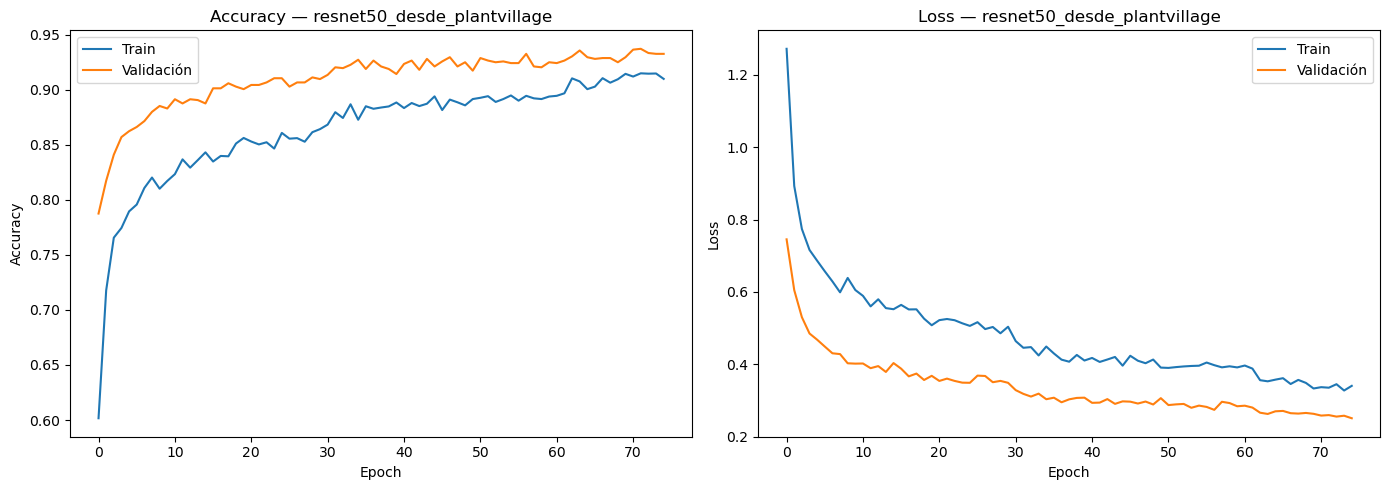

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_fase1.history['accuracy'],     label='Train')
ax1.plot(history_fase1.history['val_accuracy'], label='Validación')
ax1.set_title(f'Accuracy — {NOMBRE_MODELO}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history_fase1.history['loss'],     label='Train')
ax2.plot(history_fase1.history['val_loss'], label='Validación')
ax2.set_title(f'Loss — {NOMBRE_MODELO}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{NOMBRE_MODELO}_curvas.png', dpi=150)
plt.show()

### 8. Evaluación final en test de caña

In [9]:
test_generator.reset()

test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

predicciones = model.predict(
    test_generator,
    steps=test_generator.samples // BATCH_SIZE + 1
)
y_pred = np.argmax(predicciones, axis=1)
y_true = test_generator.classes

f1 = f1_score(y_true, y_pred, average='weighted')

print(f'\nTest Accuracy : {test_accuracy:.4f}')
print(f'Test Loss     : {test_loss:.4f}')
print(f'F1 Score      : {f1:.4f}')

nombres_clases = list(test_generator.class_indices.keys())
print('\n--- Reporte de clasificación ---')
print(classification_report(y_true, y_pred, target_names=nombres_clases))

41/41 [==============================] - 51s 1s/step

Test Accuracy : 0.9519
Test Loss     : 0.2178
F1 Score      : 0.9520

--- Reporte de clasificación ---
                  precision    recall  f1-score   support

          carbon       1.00      0.99      0.99        75
   hoja_amarilla       0.99      0.97      0.98       150
   mancha_anillo       1.00      0.98      0.99       106
    mancha_parda       0.93      0.97      0.95       150
         mosaico       0.90      0.89      0.89       150
     muermo_rojo       0.95      0.95      0.95       150
            roya       0.91      0.92      0.91       150
           sanas       0.92      0.94      0.93       150
           secas       1.00      0.96      0.98        78
tizon_bacteriano       0.99      0.98      0.99       150

        accuracy                           0.95      1309
       macro avg       0.96      0.95      0.96      1309
    weighted avg       0.95      0.95      0.95      1309



### 9. Matriz de Confusión

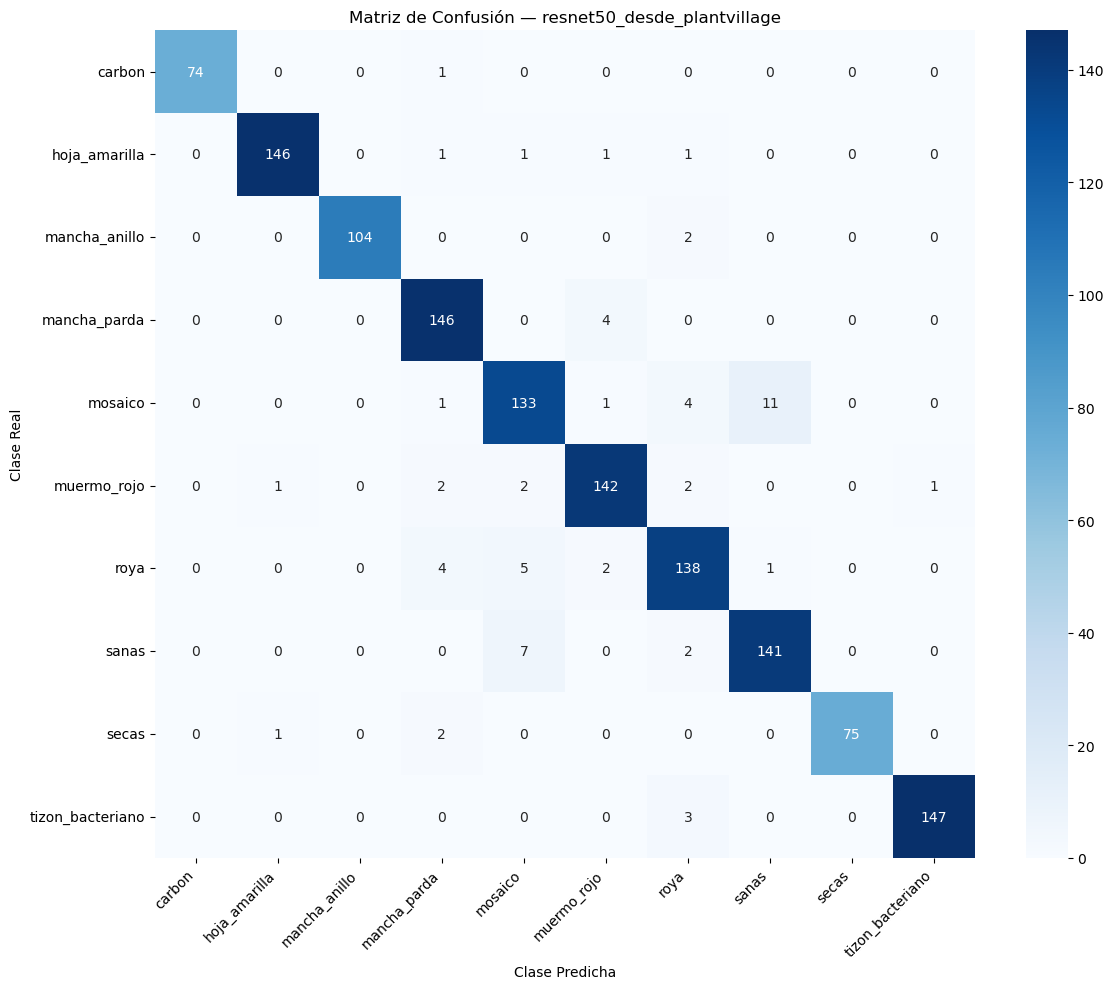

In [10]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=nombres_clases,
    yticklabels=nombres_clases
)
plt.title(f'Matriz de Confusión — {NOMBRE_MODELO}')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()